# Install Libraries
Downgraded to pandas 2.2.2 for compatability purposes

In [9]:
# Install necessary libraries
!pip install pandas==2.2.2
!pip install gspread scikit-learn pandas

# Get data from Google Sheets before beginning

In [10]:
#Google Sheets Linking (Needs user authorization)
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

In [11]:
import pandas as pd
# Open the spreadsheet by URL
spreadsheet_url = 'https://docs.google.com/spreadsheets/d/14pMQzQwy2Dl9OIhS24hyJdX1sfEdVi9SeZfGuYaMKQ0/edit?usp=drive_link'
wb = gc.open_by_url(spreadsheet_url)
sheet = wb.get_worksheet(0)

# Load data into DataFrame
data = sheet.get_all_values()
df = pd.DataFrame(data[1:], columns=data[0])

print("Sanity Check - Original Data:")
display(df.head())

Sanity Check - Original Data:


,text,label_specific,label_generic
0,Hi\n\n I am running the IR test...,human_legit,legit
1,\n\n\n\n\n\n\n\n\n\n\n\n\nSecurity Note: Trade...,human_legit,legit
2,\n\n\n\n\n\n\n\n\n\nTrade Me Offer RequestGene...,human_legit,legit
3,"Hi Tony\nNot sure why it didn't work, but I ma...",human_legit,legit
4,Kindly suggest changes\n\n--------------------...,human_legit,legit


# Preprocessing
Preprocessing out common keywords that seem to not make sense ("monkey", "jose", etc) in addition to other preprocessing data using base preprocessing from Group 1.

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Separate legit and phishing
df_legit = df[df["label_generic"] == "legit"]
df_phish = df[df["label_generic"] == "phishing"]

# Determine how many total rows you want for the final filtered dataframe
# The original code aimed for len(df) total samples, so we'll maintain that goal.
total_target_samples = len(df) # Which is 4000 from the kernel state

# Define desired percentages for the final dataset
desired_legit_ratio = 0.95
desired_phishing_ratio = 0.05

# Calculate the desired number of samples for each category based on the total target
desired_n_legit = int(total_target_samples * desired_legit_ratio)
desired_n_phish = int(total_target_samples * desired_phishing_ratio)

# Ensure that the target number of samples does not exceed the available samples
num_legit_to_sample = min(desired_n_legit, len(df_legit))
num_phish_to_sample = min(desired_n_phish, len(df_phish))

# Perform stratified sampling inside each class
# For df_legit_sample, we want 'num_legit_to_sample' rows.
# train_test_split returns two sets, we only need the first one.
if num_legit_to_sample > 0:
    if num_legit_to_sample == len(df_legit):
        df_legit_sample = df_legit.copy() # Take all legit samples if num_to_sample equals total available
    else:
        df_legit_sample, _ = train_test_split(
            df_legit,
            train_size=num_legit_to_sample, # Use the calculated absolute number
            stratify=df_legit["label_specific"],
            random_state=42
        )
else:
    df_legit_sample = pd.DataFrame(columns=df_legit.columns) # Empty DataFrame if no legit samples needed

# For df_phish_sample, we want 'num_phish_to_sample' rows.
if num_phish_to_sample > 0:
    if num_phish_to_sample == len(df_phish):
        df_phish_sample = df_phish.copy() # Take all phish samples if num_to_sample equals total available
    else:
        df_phish_sample, _ = train_test_split(
            df_phish,
            train_size=num_phish_to_sample, # Use the calculated absolute number
            stratify=df_phish["label_specific"],
            random_state=42
        )
else:
    df_phish_sample = pd.DataFrame(columns=df_phish.columns) # Empty DataFrame if no phish samples needed

# Combine
df_filtered = pd.concat([df_legit_sample, df_phish_sample]).sample(frac=1, random_state=42)

print(df_filtered["label_generic"].value_counts(normalize=True))

label_generic
legit       0.909091
phishing    0.090909
Name: proportion, dtype: float64


In [13]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

def preprocessing(text):
  #collapse spaces to make the text more concise
  text = re.sub(r'\s+', ' ', text)

  #Tokenize links + emails
  text = re.sub(r'http\S+', 'URL_TOKEN', text)
  text = re.sub(r'\S*@\S*\s?', 'EMAIL_TOKEN', text)

  #regex to keep alphabetic characters, both capitalized and lowercase, numbers, spaces, . , ! ? ' \ " < > : + = \ ( ) $ %
  #& ^ * # _ - safe. This removes emojis or foreign characters.
  pattern = r"[^a-zA-Z0-9\s.,!?/'\"<>:+=\\()$@;\[\]|%&^*#_`{}~-]"

  text = re.sub(pattern, " ", text);

  pattern2 = r"\b(monkey|jose|org|spambayes)\b"

  text = re.sub(pattern2, " ", text);

  return text.strip()

df_processed = df.copy()
for col in df_processed.columns:
    df_processed[col] = df_processed[col].apply(preprocessing)

# Vectorization

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

print("Vectorizing text...")
tfidf = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', max_features=10000)
X = tfidf.fit_transform(df['text'].astype(str))

Vectorizing text...


# Training based on generic label

In [15]:
print("Training Random Forest (Generic Label)...")

#encode before splitting
df['label_encoded'] = df['label_generic'].apply(lambda x: 1 if x == 'phishing' else 0)
y = df['label_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df['label_encoded'])

# n_estimators is the number of trees; n_jobs=-1 uses all your CPU cores
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

print("Training complete!")

Training Random Forest (Generic Label)...
Training complete!


In [16]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 1. Define the stratified k-fold cross-validation strategy
#    n_splits is k (10 folds), shuffle=True ensures randomness
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 2. Define the parameter grid for hyperparameter tuning (specific hyperparameters for different models)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]  # Inverse of regularization strength hyperparameter
}


# 3. Instantiate GridSearchCV with the stratified CV object
#    The 'cv' parameter takes the instantiated cross-validation generator
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=skf,
    scoring='f1', # Focus on a balance of precision and recall
    n_jobs=-1
)

# 4. Fit the model to the training data
print("Training Random Forest (Generic Labels) with Grid Search & Stratified K-Fold...")
grid_search.fit(X_train, y_train)

# 5. View the best parameters found
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

# Use the best estimator as the final model
clf_generic_tuned = grid_search.best_estimator_

# Update clf_generic to refer to the tuned model for consistency with earlier cell
clf_generic = clf_generic_tuned

Training Random Forest (Generic Labels) with Grid Search & Stratified K-Fold...
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV accuracy: 0.9845


# Test how well the model is performing

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
#import matplotlib.pyplot as plt

# 1. Ask the model to predict the 'Test' set
print("Predicting on test data...")
y_pred = rf_model.predict(X_test)

# 2. Print the text-based report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Predicting on test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       400
           1       0.98      0.99      0.99       400

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800



Model expects: 10000 words
Current TF-IDF has: 10000 words


/tmp/ipython-input-243/1915807345.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='word', data=feature_importance_df, palette='viridis')


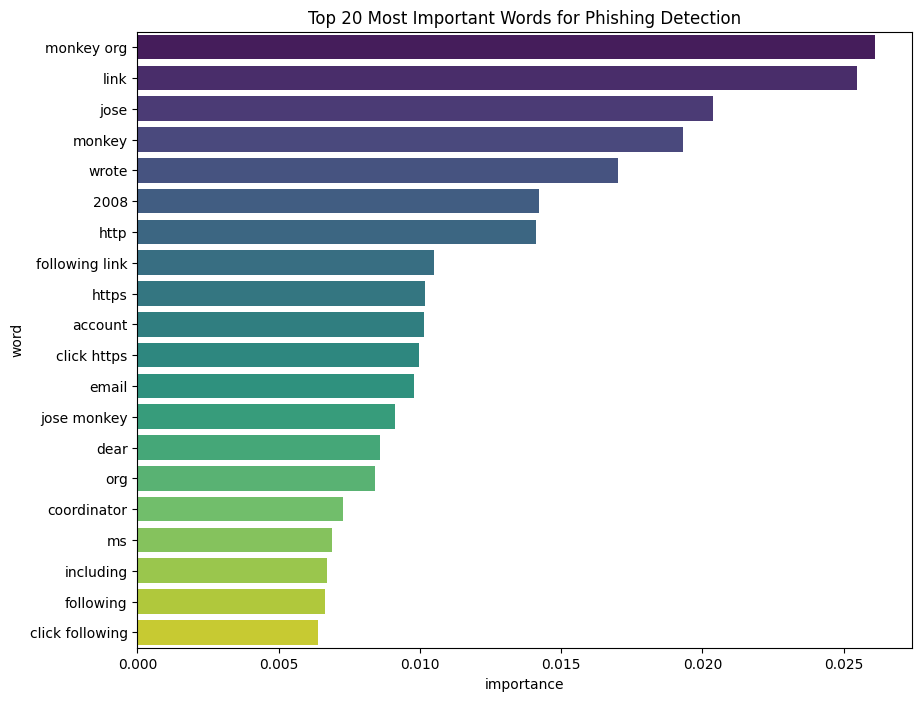

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get the scores from the Random Forest
importances = grid_search.best_estimator_.feature_importances_

# 2. Map those scores back to the actual words from the TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

#Safety Check
num_features_in_model = len(importances)

print(f"Model expects: {num_features_in_model} words")
print(f"Current TF-IDF has: {len(feature_names)} words")

# 3. Organize into a readable format
feature_importance_df = pd.DataFrame({'word': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(20)

# 4. Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='word', data=feature_importance_df, palette='viridis')
plt.title('Top 20 Most Important Words for Phishing Detection')
plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder

print("Training Random Forest (Specific Label)...")

# Use LabelEncoder to handle the 4 distinct categories
le = LabelEncoder()
df['specific_label_encoded'] = le.fit_transform(df['label_specific'])
y_spe = df['specific_label_encoded']

# Print the mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Label Mapping: {mapping}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_spe, test_size=0.2, random_state=42, stratify=y
)

# Train the model (RandomForestClassifier handles multi-class automatically)
rf_model_specific = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_model_specific.fit(X_train, y_train)

print("Training complete!")

Training Random Forest (Specific Label)...
Label Mapping: {'human_legit': np.int64(0), 'human_phishing': np.int64(1), 'llm_legit': np.int64(2), 'llm_phishing': np.int64(3)}
Training complete!


In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 1. Define the stratified k-fold cross-validation strategy
#    n_splits is k (10 folds), shuffle=True ensures randomness
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 2. Define the parameter grid for hyperparameter tuning (specific hyperparameters for different models)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]  # Inverse of regularization strength hyperparameter
}


# 3. Instantiate GridSearchCV with the stratified CV object
#    The 'cv' parameter takes the instantiated cross-validation generator
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=skf,
    scoring='f1_macro', # Focus on a balance of precision and recall
    n_jobs=-1
)

# 4. Fit the model to the training data
print("Training Random Forest (Specific Labels) with Grid Search & Stratified K-Fold...")
grid_search.fit(X_train, y_train)

# 5. View the best parameters found
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

# Use the best estimator as the final model
clf_specific_tuned = grid_search.best_estimator_

# Update clf_specific to refer to the tuned model for consistency with earlier cell
clf_specific = clf_specific_tuned

Training Random Forest (Specific Labels) with Grid Search & Stratified K-Fold...
Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy: 0.9866


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict on the test data
print("Predicting on test data...")
y_pred = clf_specific.predict(X_test)

# 2. Print the text-based report
# 'le.classes_' ensures the labels 0-3 match human_legit, llm_phishing, etc.
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Predicting on test data...

--- Classification Report ---
                precision    recall  f1-score   support

   human_legit       0.99      0.99      0.99       182
human_phishing       1.00      0.99      0.99       189
     llm_legit       0.98      0.97      0.97       218
  llm_phishing       0.96      0.98      0.97       211

      accuracy                           0.98       800
     macro avg       0.98      0.98      0.98       800
  weighted avg       0.98      0.98      0.98       800



/tmp/ipython-input-243/3584511292.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category_weight', y='word', data=human_phish_df, ax=ax1, palette='Reds_r')
/tmp/ipython-input-243/3584511292.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category_weight', y='word', data=llm_phish_df, ax=ax2, palette='Blues_r')


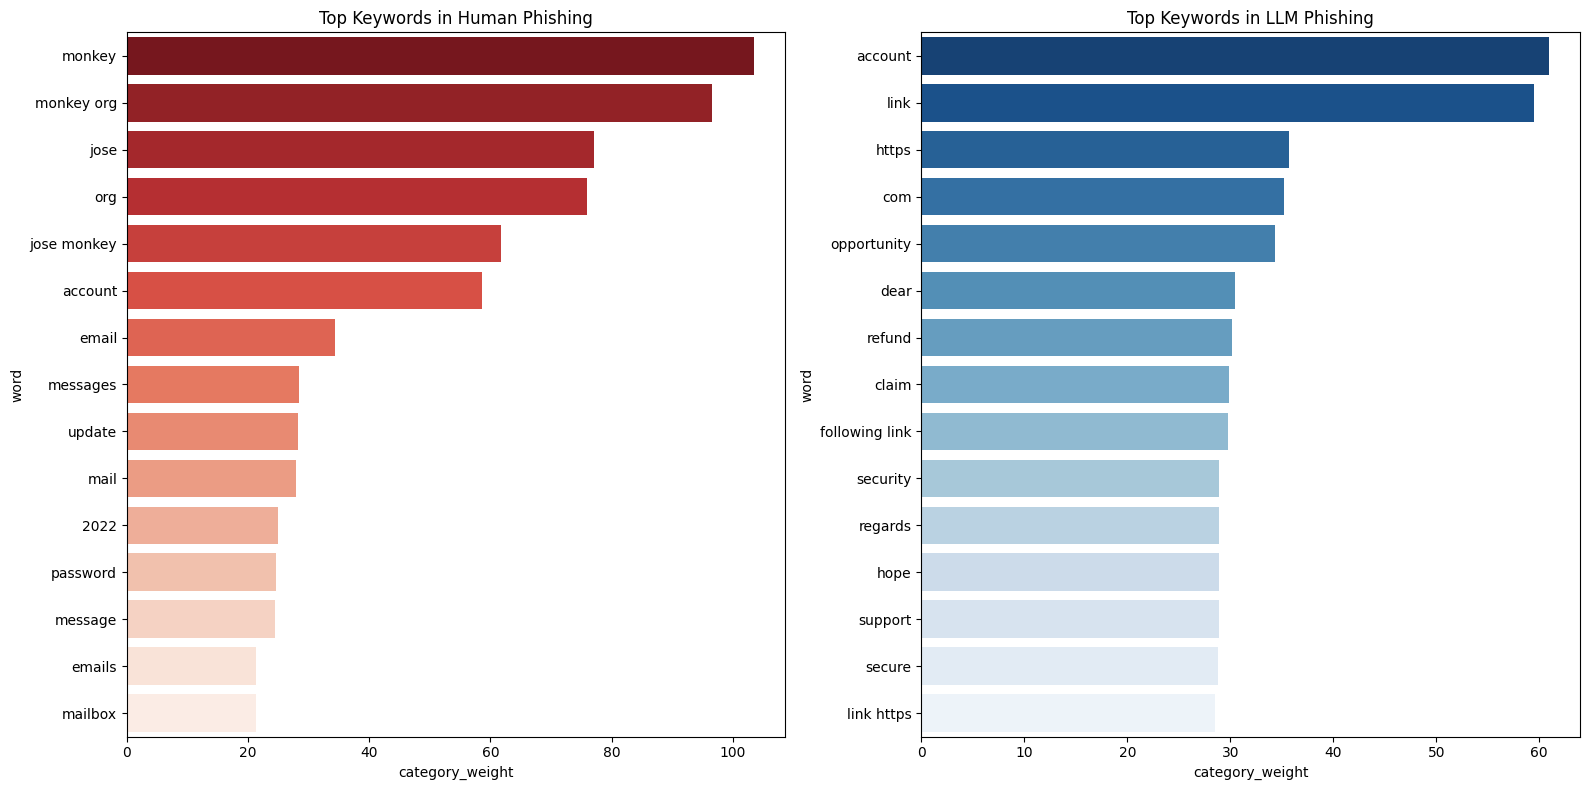

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get global importances from the best model
importances = grid_search.best_estimator_.feature_importances_
feature_names = tfidf.get_feature_names_out()

# 2. Create a DataFrame for all features
all_features_df = pd.DataFrame({'word': feature_names, 'importance': importances})

# 3. Function to find top words specific to a category
def get_top_words_for_category(category_name, top_n=15):
    # Filter the original dataframe for just this category
    category_docs = df[df['label_specific'] == category_name]['text']

    # Use the existing TF-IDF to see how much these words actually appear in this category
    # We sum the TF-IDF scores for these documents
    weights = tfidf.transform(category_docs).sum(axis=0).A1

    # Merge with the Random Forest importance to find words that are BOTH important AND frequent here
    temp_df = pd.DataFrame({'word': feature_names, 'category_weight': weights})
    category_importance = temp_df.merge(all_features_df, on='word')

    # Sort by a combined score or just the frequency within the category
    return category_importance.sort_values(by='category_weight', ascending=False).head(top_n)

# 4. Get data for both specific phishing types
human_phish_df = get_top_words_for_category('human_phishing')
llm_phish_df = get_top_words_for_category('llm_phishing')

# 5. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Human Phishing Plot
sns.barplot(x='category_weight', y='word', data=human_phish_df, ax=ax1, palette='Reds_r')
ax1.set_title('Top Keywords in Human Phishing')

# LLM Phishing Plot
sns.barplot(x='category_weight', y='word', data=llm_phish_df, ax=ax2, palette='Blues_r')
ax2.set_title('Top Keywords in LLM Phishing')

plt.tight_layout()
plt.show()

/tmp/ipython-input-243/3204063561.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='source_weight', y='word', data=human_source_df, ax=ax1, palette='Greens_r')
/tmp/ipython-input-243/3204063561.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='source_weight', y='word', data=llm_source_df, ax=ax2, palette='Purples_r')


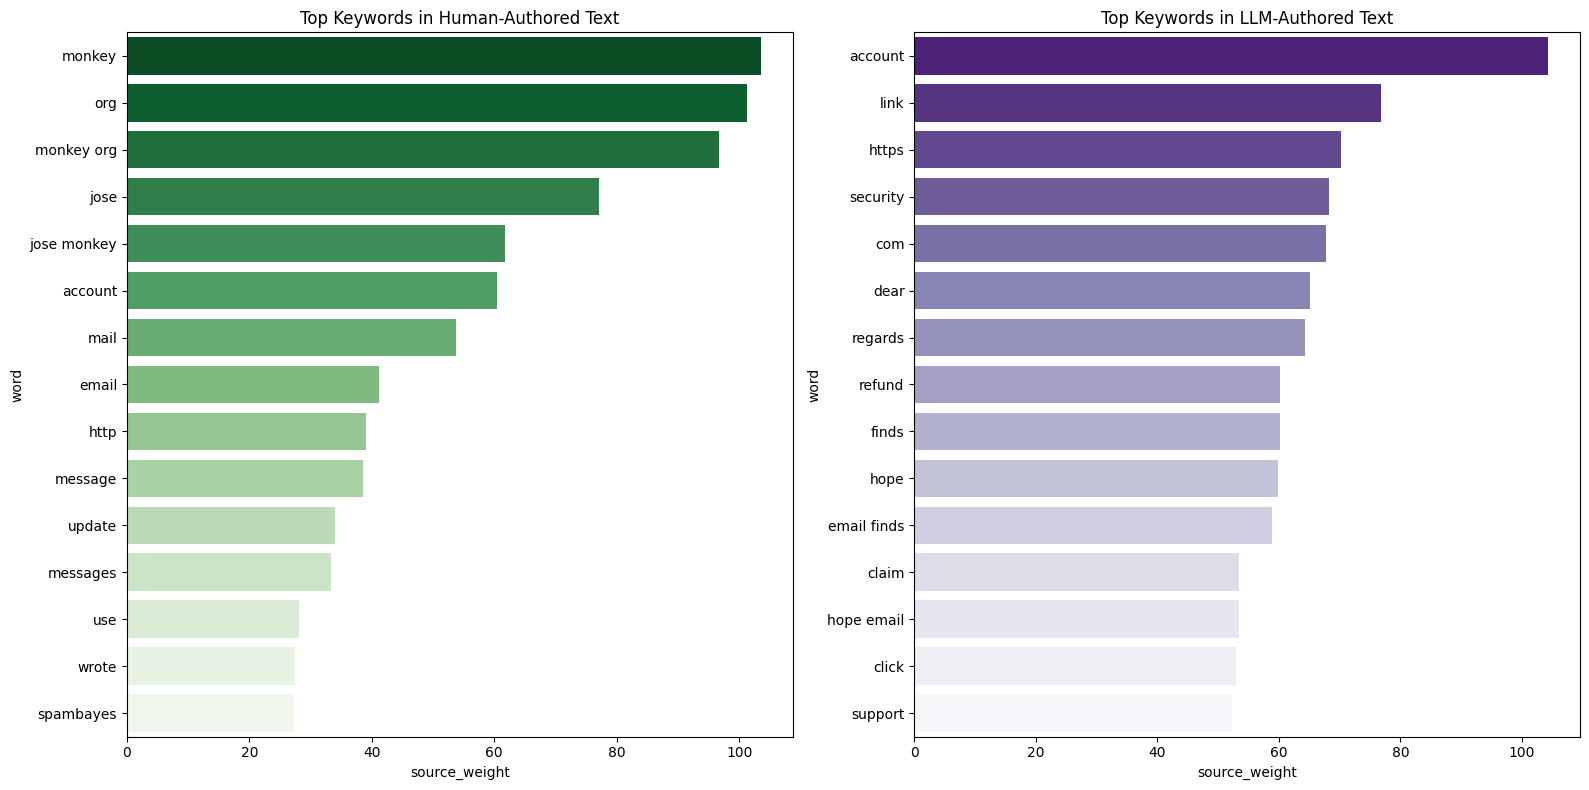

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get global importances from your trained model
importances = grid_search.best_estimator_.feature_importances_
feature_names = tfidf.get_feature_names_out()
all_features_df = pd.DataFrame({'word': feature_names, 'importance': importances})

# 2. Function to find top words by source (Human vs LLM)
def get_top_words_by_source(source_type, top_n=15):
    # Filter documents where the label contains 'human' or 'llm'
    source_docs = df[df['label_specific'].str.contains(source_type)]['text']

    # Calculate how much these words appear in this source type specifically
    weights = tfidf.transform(source_docs).sum(axis=0).A1

    temp_df = pd.DataFrame({'word': feature_names, 'source_weight': weights})
    source_importance = temp_df.merge(all_features_df, on='word')

    # Sort by the frequency/weight within that source
    return source_importance.sort_values(by='source_weight', ascending=False).head(top_n)

# 3. Get data for Human-authored vs LLM-authored
human_source_df = get_top_words_by_source('human')
llm_source_df = get_top_words_by_source('llm')

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Human Signature Plot
sns.barplot(x='source_weight', y='word', data=human_source_df, ax=ax1, palette='Greens_r')
ax1.set_title('Top Keywords in Human-Authored Text')

# LLM Signature Plot
sns.barplot(x='source_weight', y='word', data=llm_source_df, ax=ax2, palette='Purples_r')
ax2.set_title('Top Keywords in LLM-Authored Text')

plt.tight_layout()
plt.show()

# Task
Calculate the target number of legit and phishing samples based on `legit_percent` and `phishing_percent`, ensuring not to exceed the original counts for each category. Then, perform stratified sampling by `label_specific` within the 'legit' and 'phishing' groups, distributing the target counts proportionally among the specific labels. Finally, concatenate the sampled data into a new DataFrame named `df_stratified_sampled`.

## create_stratified_sampled_dataframe

### Subtask:
Calculate the target number of legit and phishing samples based on the desired percentages and the available data, ensuring not to exceed the original counts for each category. Then, perform stratified sampling by `label_specific` within the 'legit' and 'phishing' groups, distributing the target counts proportionally among the specific labels. Finally, concatenate the sampled data into a new DataFrame named `df_stratified_sampled`.


## Summary:

### Data Analysis Key Findings
*   A new DataFrame, `df_stratified_sampled`, was successfully created by performing stratified sampling based on the `label_specific` column within the 'legit' and 'phishing' groups.
*   The sampling ensured that the target number of 'legit' and 'phishing' samples, derived from specified percentages, did not exceed their respective original counts in the dataset.
*   The proportional representation of `label_specific` categories within both 'legit' and 'phishing' groups was maintained in the `df_stratified_sampled` DataFrame, preserving the underlying data distribution.

### Insights or Next Steps
*   The `df_stratified_sampled` DataFrame provides a balanced and representative subset of the original data, suitable for training machine learning models or further analysis without being skewed by class imbalance.
*   The next step should involve a thorough validation of the `df_stratified_sampled` DataFrame to confirm that the `label_specific` distributions within the 'legit' and 'phishing' categories precisely match the desired proportions.
